# Euro 2024 Expected Goals (xG) Model

---

This notebook builds an **expected goals (xG)** model from scratch using StatsBomb's free
open shot event data for **UEFA Euro 2024**, and compares it against StatsBomb's own
published xG values for the same shots.

| | |
|---|---|
| **Dataset** | StatsBomb Open Data — UEFA Euro 2024 (competition_id=55, season_id=282) |
| **Target** | P(shot results in a goal) |
| **Models** | Logistic Regression · Random Forest · Gradient Boosting · Hist Gradient Boosting |
| **Tracking** | MLflow |

---

**Sections**
1. [Imports & Configuration](#1)
2. [Data Loading & Overview](#2)
3. [Exploratory Data Analysis](#3)
4. [Feature Engineering](#4)
5. [Train / Test Split](#5)
6. [Model Training & Experiment Tracking](#6)
7. [Model Comparison](#7)
8. [Best Model Evaluation](#8)
9. [Feature Importance](#9)
10. [Team Over/Underperformance](#10)
11. [Summary](#11)

<a id='1'></a>
## 1 · Imports & Configuration

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    log_loss, roc_auc_score, brier_score_loss, roc_curve
)
from sklearn.calibration import calibration_curve

from data_preprocessing import load_data, engineer_features, clean_data, get_X_y, calculate_angle, calculate_distance
from models import build_pipelines

# ── Global plot style ─────────────────────────────────────────────────
PALETTE   = 'coolwarm'
ACCENT    = '#2E86AB'
HIGHLIGHT = '#E84855'
GOAL_COLOR = '#ad993c'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
})

<a id='2'></a>
## 2 · Data Loading & Overview

Shot data was collected up-front with `src/fetch_data.py`, which pulls every match's event
data from StatsBomb's free [open-data](https://github.com/statsbomb/open-data) repository
and caches the flattened shot events to `data/euro2024_shots.csv`.

In [2]:
df_raw = load_data('../data/euro2024_shots.csv')

print(f"Shots   : {len(df_raw):,}")
print(f"Matches : {df_raw['match_id'].nunique()}")
print(f"Goals   : {(df_raw['shot_outcome_name'] == 'Goal').sum()} "
      f"({(df_raw['shot_outcome_name'] == 'Goal').mean():.1%} conversion rate)")
df_raw.head(8)

Shots   : 1,316
Matches : 51
Goals   : 107 (8.1% conversion rate)


,match_id,team_name,player_name,minute,second,period,location_x,location_y,play_pattern_name,shot_statsbomb_xg,shot_outcome_name,shot_type_name,shot_technique_name,shot_body_part_name,shot_first_time,shot_one_on_one,shot_open_goal,shot_aerial_won,under_pressure
0,3930166,Czech Republic,Pavel Šulc,3,39,1,103.0,33.9,From Goal Kick,0.060549,Blocked,Open Play,Normal,Right Foot,NaN,NaN,NaN,NaN,NaN
1,3930166,Portugal,Cristiano Ronaldo dos Santos Aveiro,7,30,1,108.6,40.1,Regular Play,0.054355,Off T,Open Play,Normal,Head,NaN,NaN,NaN,NaN,NaN
2,3930166,Portugal,Nuno Mendes,16,9,1,89.6,25.3,Regular Play,0.007153,Off T,Open Play,Normal,Left Foot,NaN,NaN,NaN,NaN,NaN
3,3930166,Portugal,Rúben Santos Gato Alves Dias,21,19,1,99.7,52.2,From Throw In,0.031687,Blocked,Open Play,Normal,Right Foot,NaN,NaN,NaN,NaN,NaN
4,3930166,Portugal,João Pedro Cavaco Cancelo,22,56,1,104.7,25.1,From Corner,0.028343,Blocked,Open Play,Normal,Right Foot,NaN,NaN,NaN,NaN,True
5,3930166,Portugal,Bruno Miguel Borges Fernandes,23,17,1,92.6,20.6,From Corner,0.005574,Blocked,Open Play,Normal,Right Foot,NaN,NaN,NaN,NaN,NaN
6,3930166,Portugal,Cristiano Ronaldo dos Santos Aveiro,31,14,1,109.8,36.7,Regular Play,0.491669,Saved,Open Play,Normal,Left Foot,True,NaN,NaN,NaN,NaN
7,3930166,Portugal,Vitor Machado Ferreira,31,18,1,96.7,32.6,Regular Play,0.037158,Saved,Open Play,Normal,Right Foot,NaN,NaN,NaN,NaN,NaN


In [3]:
df_raw['shot_outcome_name'].value_counts()

shot_outcome_name
Off T               397
Blocked             386
Saved               312
Goal                107
Wayward              81
Post                 24
Saved to Post         5
Saved Off Target      4
Name: count, dtype: int64

<a id='3'></a>
## 3 · Exploratory Data Analysis

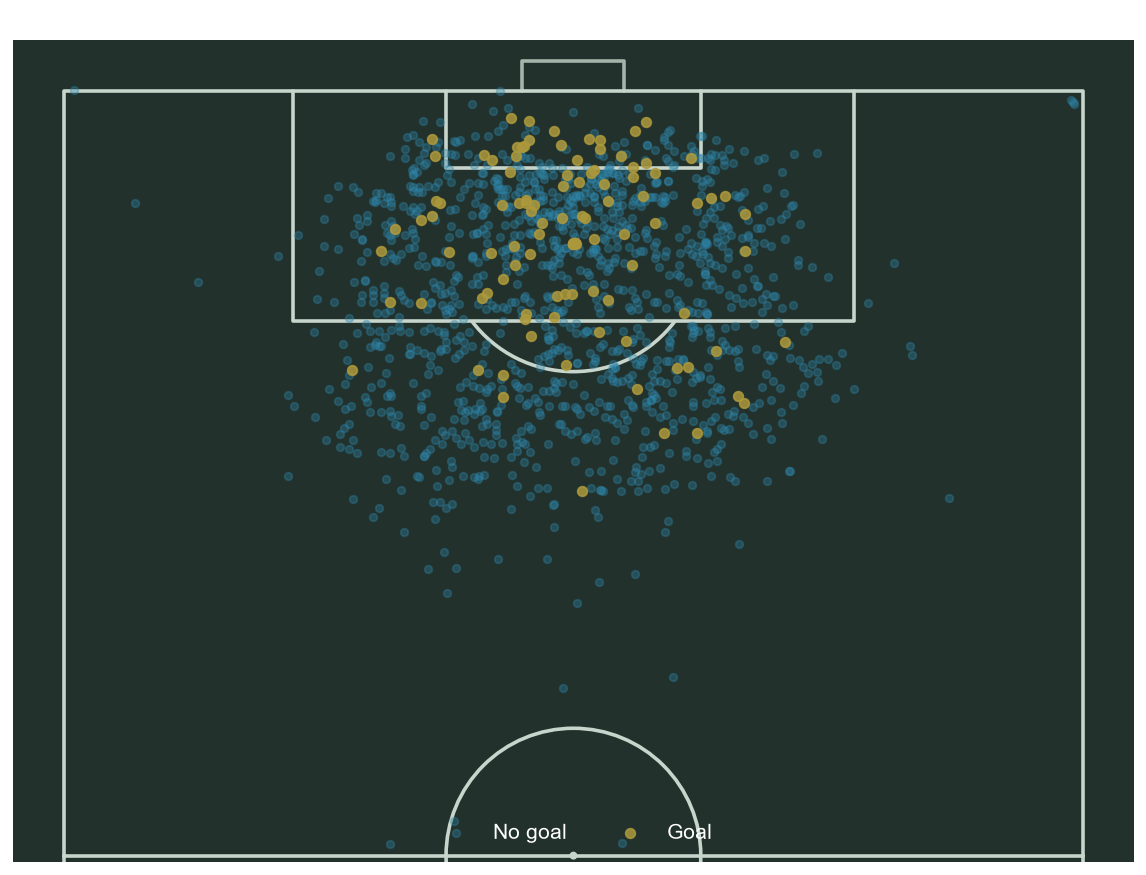

In [4]:
# ── 3.1  Shot map ─────────────────────────────────────────────────
from mplsoccer import VerticalPitch

goals = df_raw[df_raw['shot_outcome_name'] == 'Goal']
non_goals = df_raw[df_raw['shot_outcome_name'] != 'Goal']

pitch = VerticalPitch(pad_bottom=0.5, half=True, goal_type='box', goal_alpha=0.8,
                       pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(9, 8))

pitch.scatter(non_goals['location_x'], non_goals['location_y'],
              c=ACCENT, marker='o', s=18, alpha=0.35, ax=ax, label='No goal')
pitch.scatter(goals['location_x'], goals['location_y'],
              c=GOAL_COLOR, marker='o', s=28, alpha=0.85, ax=ax, label='Goal')
ax.legend(facecolor='#22312b', labelcolor='white', loc='lower center', ncol=2, frameon=False)
ax.set_title('All Euro 2024 Shots', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shot_map.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

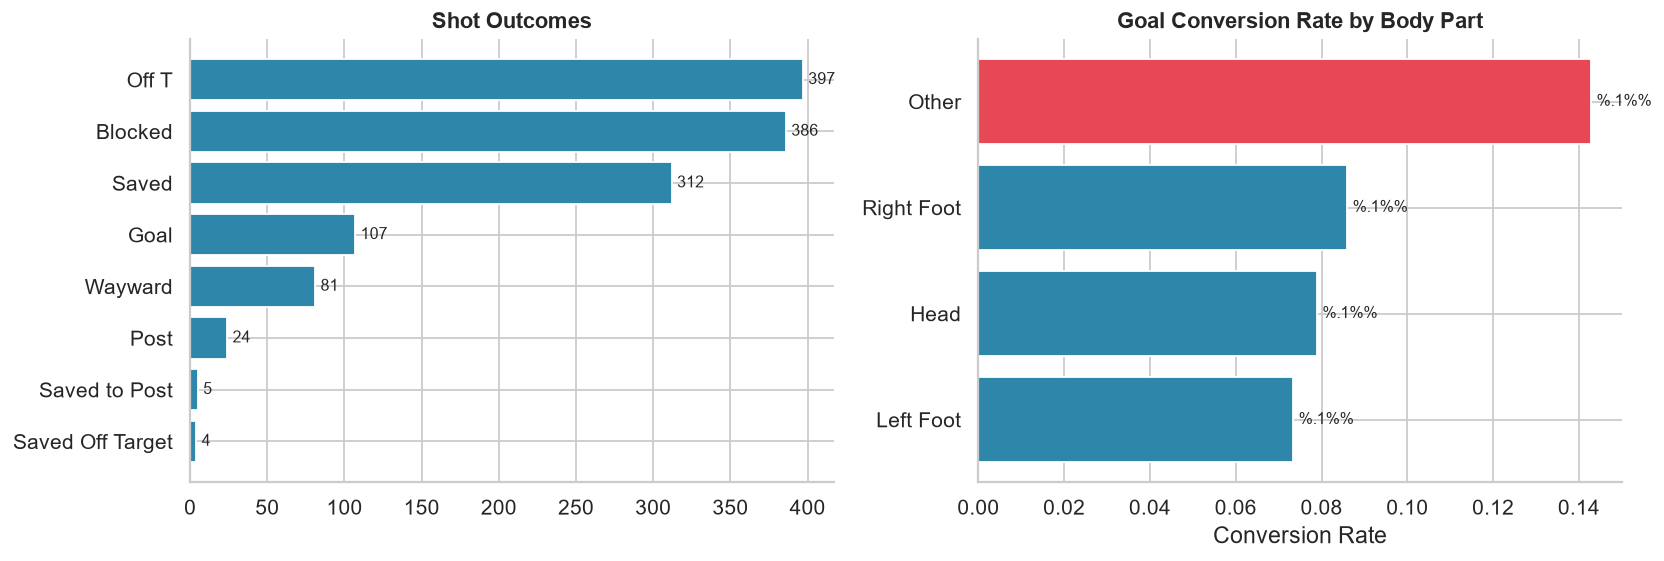

In [5]:
# ── 3.2  Shot outcome breakdown & body part ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

outcome_counts = df_raw['shot_outcome_name'].value_counts()
axes[0].barh(outcome_counts.index[::-1], outcome_counts.values[::-1], color=ACCENT, edgecolor='white')
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)
axes[0].set_title('Shot Outcomes')

body_part_goal_rate = df_raw.groupby('shot_body_part_name')['shot_outcome_name'] \
    .apply(lambda s: (s == 'Goal').mean()).sort_values()
colors_bp = [HIGHLIGHT if v == body_part_goal_rate.max() else ACCENT for v in body_part_goal_rate.values]
axes[1].barh(body_part_goal_rate.index, body_part_goal_rate.values, color=colors_bp, edgecolor='white')
axes[1].bar_label(axes[1].containers[0], fmt='%.1%%', padding=3, fontsize=9)
axes[1].set_title('Goal Conversion Rate by Body Part')
axes[1].set_xlabel('Conversion Rate')

plt.tight_layout()
plt.savefig('../outputs/shot_outcomes.png', bbox_inches='tight')
plt.show()

<a id='4'></a>
## 4 · Feature Engineering

Following the standard xG modelling approach, raw `(x, y)` shot locations are converted into
geometric features, and shot context is captured as boolean/one-hot flags.

| Category | Features | Rationale |
|---|---|---|
| **Geometry** | `angle`, `distance` | Wider angle & shorter distance to goal → higher quality chance |
| **Body part** | `header`, `preferable_side` | Headers and off-side-foot shots tend to score less often |
| **Context** | `shot_first_time`, `shot_one_on_one`, `shot_open_goal`, `shot_aerial_won`, `under_pressure` | Situational factors that affect finishing difficulty |
| **Shot type** | `technique_*`, `type_*` (one-hot) | Penalties and volleys behave very differently from normal open-play strikes |

In [6]:
df = engineer_features(df_raw.copy())
df = clean_data(df)

print(f"Shape after engineering : {df.shape}")
df[['angle', 'distance', 'header', 'preferable_side', 'goal']].describe().round(2)

Shape after engineering : (1316, 33)


,angle,distance,header,preferable_side,goal
count,1316.00,1316.00,1316.00,1316.00,1316.00
mean,25.26,17.59,0.17,0.41,0.08
std,14.67,8.99,0.38,0.49,0.27
min,0.00,1.60,0.00,0.00,0.00
25%,15.35,10.45,0.00,0.00,0.00
50%,19.82,16.52,0.00,0.00,0.00
75%,31.91,23.58,0.00,1.00,0.00
max,136.40,72.01,1.00,1.00,1.00


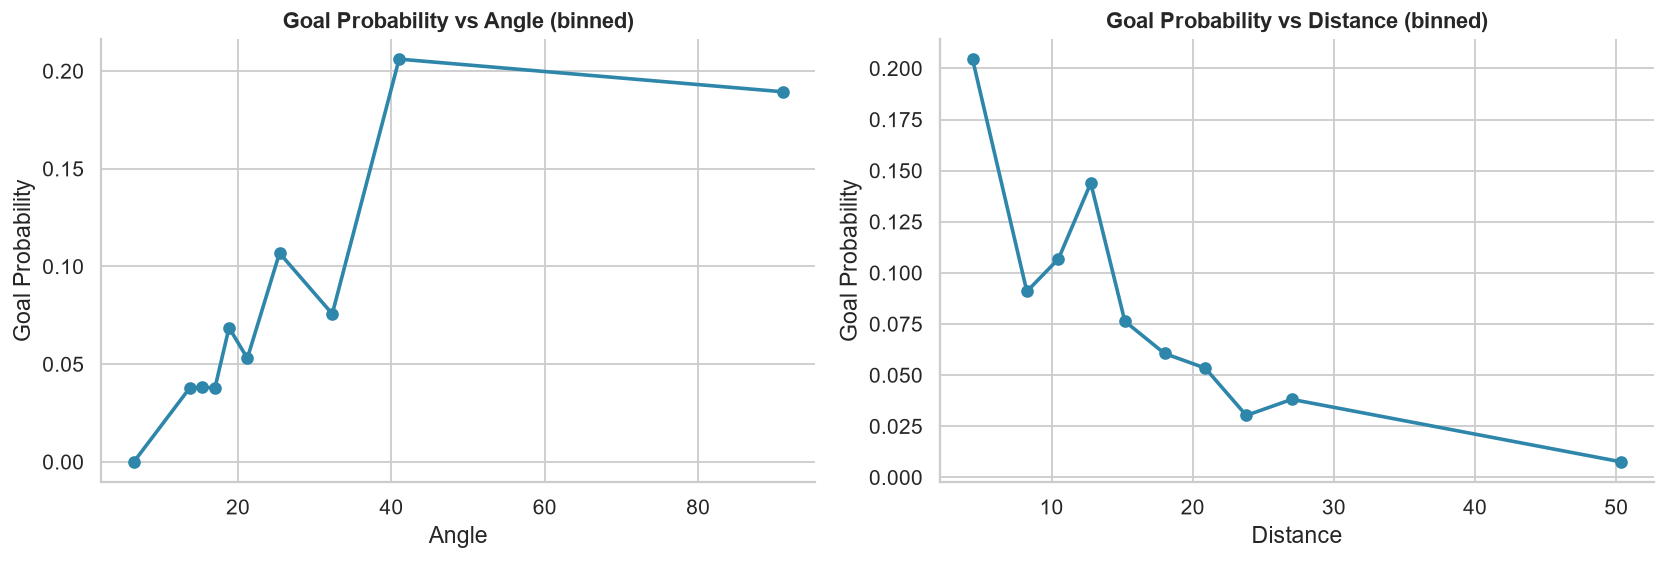

In [7]:
# ── Angle & distance vs goal probability ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, feat in zip(axes, ['angle', 'distance']):
    bins = pd.qcut(df[feat], 10, duplicates='drop')
    goal_rate = df.groupby(bins, observed=True)['goal'].mean()
    bin_mid = [interval.mid for interval in goal_rate.index]
    ax.plot(bin_mid, goal_rate.values, marker='o', color=ACCENT, linewidth=2)
    ax.set_xlabel(feat.title())
    ax.set_ylabel('Goal Probability')
    ax.set_title(f'Goal Probability vs {feat.title()} (binned)')

plt.tight_layout()
plt.savefig('../outputs/feature_scatter.png', bbox_inches='tight')
plt.show()

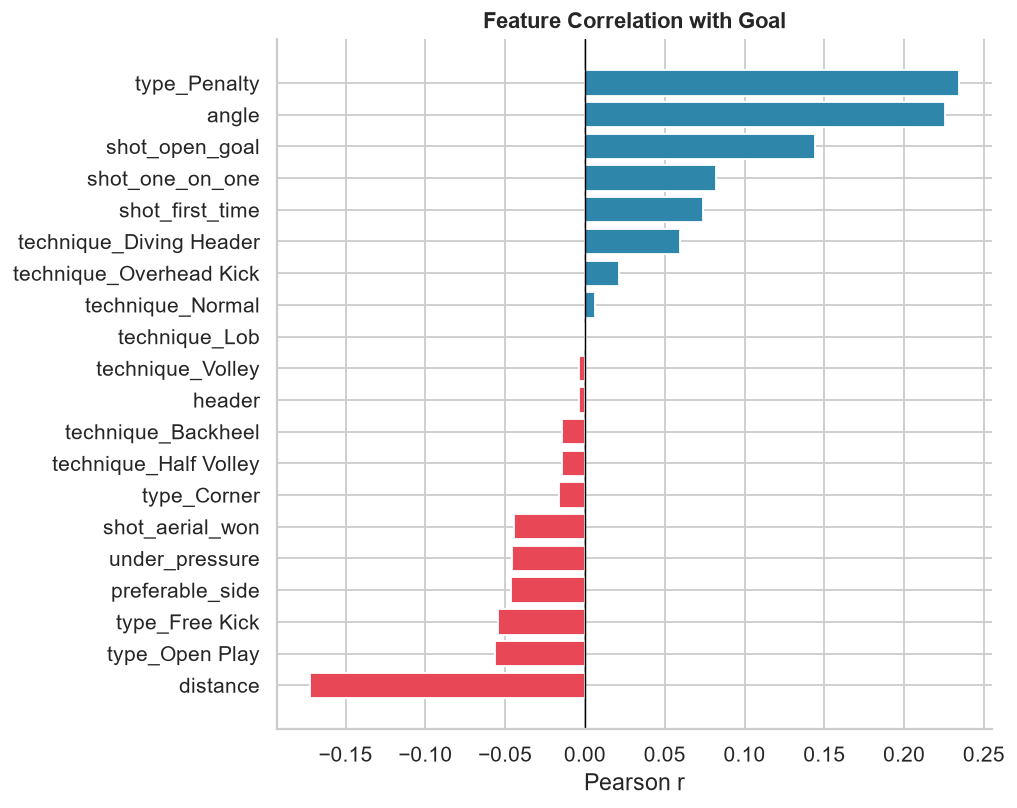

Features : 20
Samples  : 1,316


In [8]:
# ── Correlation of engineered features with goal ───────────────────────────────────────────────
X, y = get_X_y(df)
corr = X.assign(goal=y).corr()['goal'].drop('goal').sort_values()

fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(corr))))
colors_bar = [ACCENT if v >= 0 else HIGHLIGHT for v in corr.values]
ax.barh(corr.index, corr.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Goal')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig('../outputs/correlation_analysis.png', bbox_inches='tight')
plt.show()

print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]:,}")

<a id='5'></a>
## 5 · Train / Test Split

An **80 / 20 stratified split** is used so the (relatively rare) goal class keeps the same
ratio in both train and test sets.

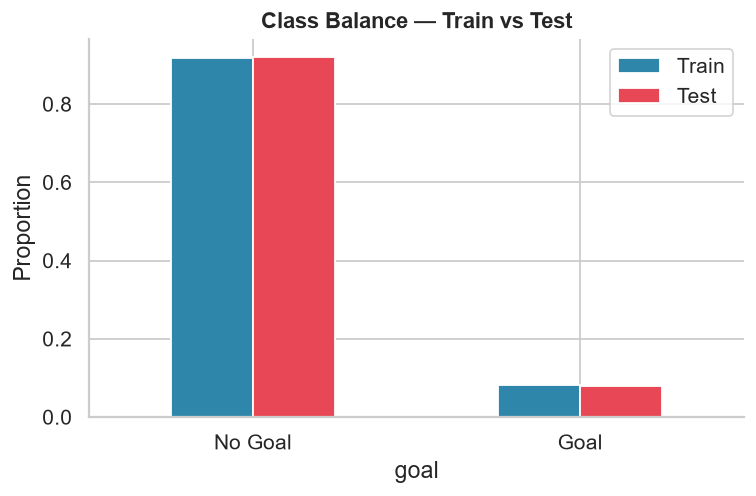

Train: 1,052 shots (8.2% goals)
Test : 264 shots (8.0% goals)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

fig, ax = plt.subplots(figsize=(6, 4))
counts = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True),
    'Test':  y_test.value_counts(normalize=True),
}).rename(index={0: 'No Goal', 1: 'Goal'})
counts.plot(kind='bar', ax=ax, color=[ACCENT, HIGHLIGHT], edgecolor='white')
ax.set_ylabel('Proportion')
ax.set_title('Class Balance — Train vs Test')
ax.set_xticklabels(counts.index, rotation=0)
plt.tight_layout()
plt.savefig('../outputs/train_test_split.png', bbox_inches='tight')
plt.show()

print(f"Train: {len(X_train):,} shots ({y_train.mean():.1%} goals)")
print(f"Test : {len(X_test):,} shots ({y_test.mean():.1%} goals)")

<a id='6'></a>
## 6 · Model Training & Experiment Tracking

Each model is wrapped in a **scikit-learn Pipeline** (StandardScaler → classifier) and
evaluated with stratified 5-fold cross-validation (ROC-AUC). All runs are logged to **MLflow**.

In [10]:
mlflow.set_experiment('euro2024_xg_model')
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipelines = build_pipelines()
results   = []
all_proba = {}

for name, pipeline in pipelines.items():
    with mlflow.start_run(run_name=name):
        cv_auc = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

        pipeline.fit(X_train, y_train)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        all_proba[name] = y_proba

        row = {
            'Model':    name,
            'CV AUC':   round(cv_auc.mean(), 4),
            'CV Std':   round(cv_auc.std(), 4),
            'Log Loss': round(log_loss(y_test, y_proba), 4),
            'ROC AUC':  round(roc_auc_score(y_test, y_proba), 4),
            'Brier':    round(brier_score_loss(y_test, y_proba), 4),
        }
        results.append(row)

        mlflow.log_params({'model': name})
        mlflow.log_metrics({
            'cv_auc': row['CV AUC'], 'cv_std': row['CV Std'],
            'test_log_loss': row['Log Loss'], 'test_roc_auc': row['ROC AUC'], 'test_brier': row['Brier'],
        })
        mlflow.sklearn.log_model(pipeline, artifact_path='model')

results_df = pd.DataFrame(results).sort_values('Log Loss').reset_index(drop=True)
results_df.style.background_gradient(subset=['Log Loss', 'Brier'], cmap='RdYlGn_r') \
                .background_gradient(subset=['ROC AUC'], cmap='RdYlGn') \
                .format(precision=4)

2026/08/24 12:10:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/24 12:10:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/24 12:10:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/24 12:11:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


,Model,CV AUC,CV Std,Log Loss,ROC AUC,Brier
0,RandomForest,0.7658,0.0336,0.2536,0.7278,0.0690
1,LogisticRegression,0.7507,0.0323,0.2557,0.7370,0.0710
2,GradientBoosting,0.7317,0.0191,0.2828,0.6685,0.0764
3,HistGradientBoosting,0.7421,0.0494,0.4296,0.6265,0.0875


<a id='7'></a>
## 7 · Model Comparison

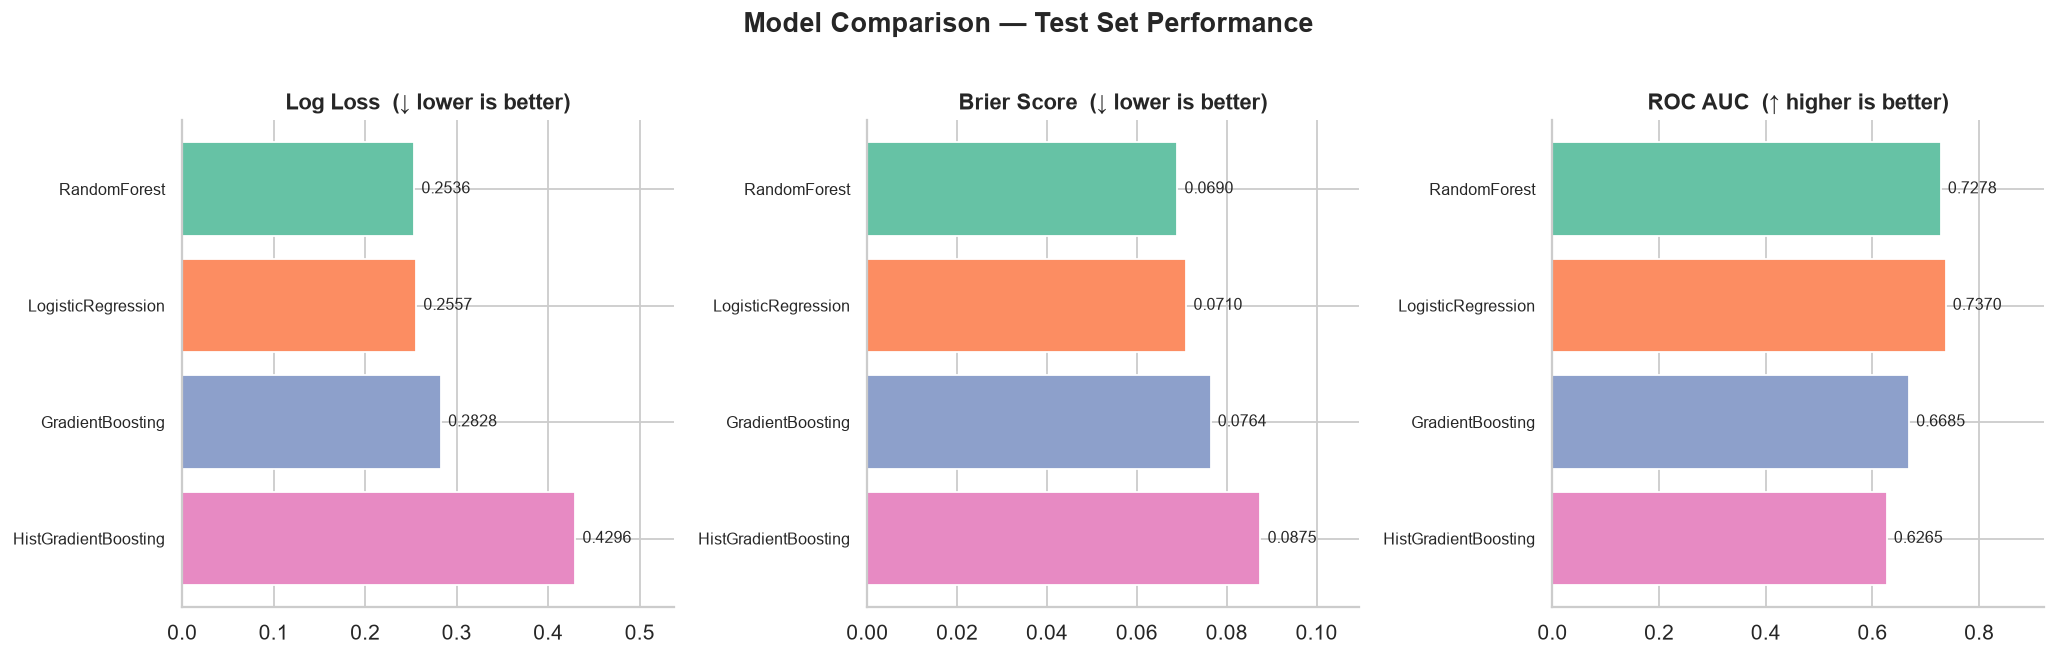

In [11]:
ordered   = results_df['Model'].tolist()
pal       = sns.color_palette('Set2', len(ordered))
color_map = dict(zip(ordered, pal))
bar_colors = [color_map[m] for m in results_df['Model']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in zip(axes,
                              ['Log Loss', 'Brier', 'ROC AUC'],
                              ['Log Loss  (↓ lower is better)',
                               'Brier Score  (↓ lower is better)',
                               'ROC AUC  (↑ higher is better)']):
    bars = ax.barh(results_df['Model'][::-1], results_df[metric][::-1],
                   color=bar_colors[::-1], edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
    ax.set_title(title)
    ax.set_xlim(0, results_df[metric].max() * 1.25)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Model Comparison — Test Set Performance', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', bbox_inches='tight')
plt.show()

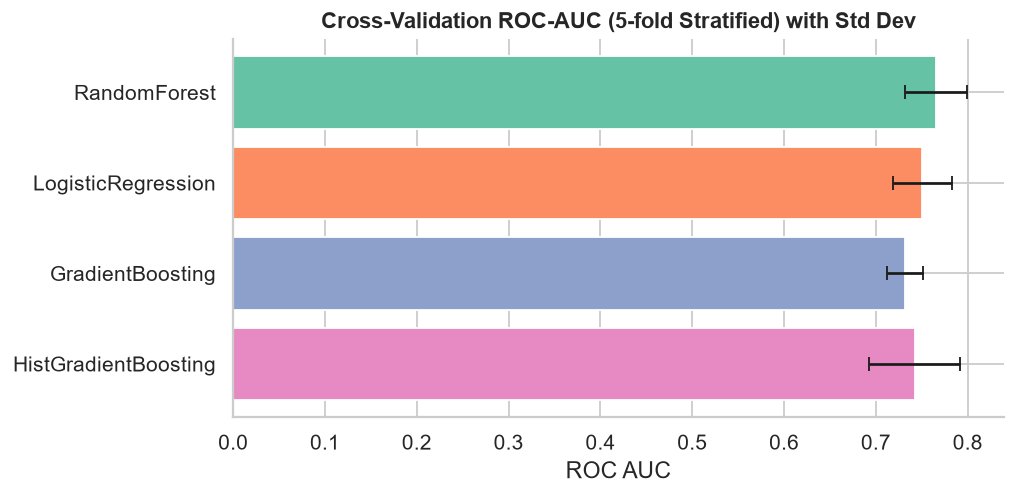

In [12]:
# CV AUC with error bars
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(results_df['Model'][::-1], results_df['CV AUC'][::-1],
        xerr=results_df['CV Std'][::-1], color=bar_colors[::-1],
        edgecolor='white', capsize=4)
ax.set_title('Cross-Validation ROC-AUC (5-fold Stratified) with Std Dev')
ax.set_xlabel('ROC AUC')
plt.tight_layout()
plt.savefig('../outputs/cv_comparison.png', bbox_inches='tight')
plt.show()

<a id='8'></a>
## 8 · Best Model Evaluation

In [13]:
best_name   = results_df.iloc[0]['Model']
best_pipeline = pipelines[best_name]
y_proba_best  = all_proba[best_name]

print(f"Best model : {best_name}")
print(f"Log Loss   : {results_df.iloc[0]['Log Loss']}")
print(f"ROC AUC    : {results_df.iloc[0]['ROC AUC']}")
print(f"Brier      : {results_df.iloc[0]['Brier']}")

Best model : RandomForest
Log Loss   : 0.2536
ROC AUC    : 0.7278
Brier      : 0.069


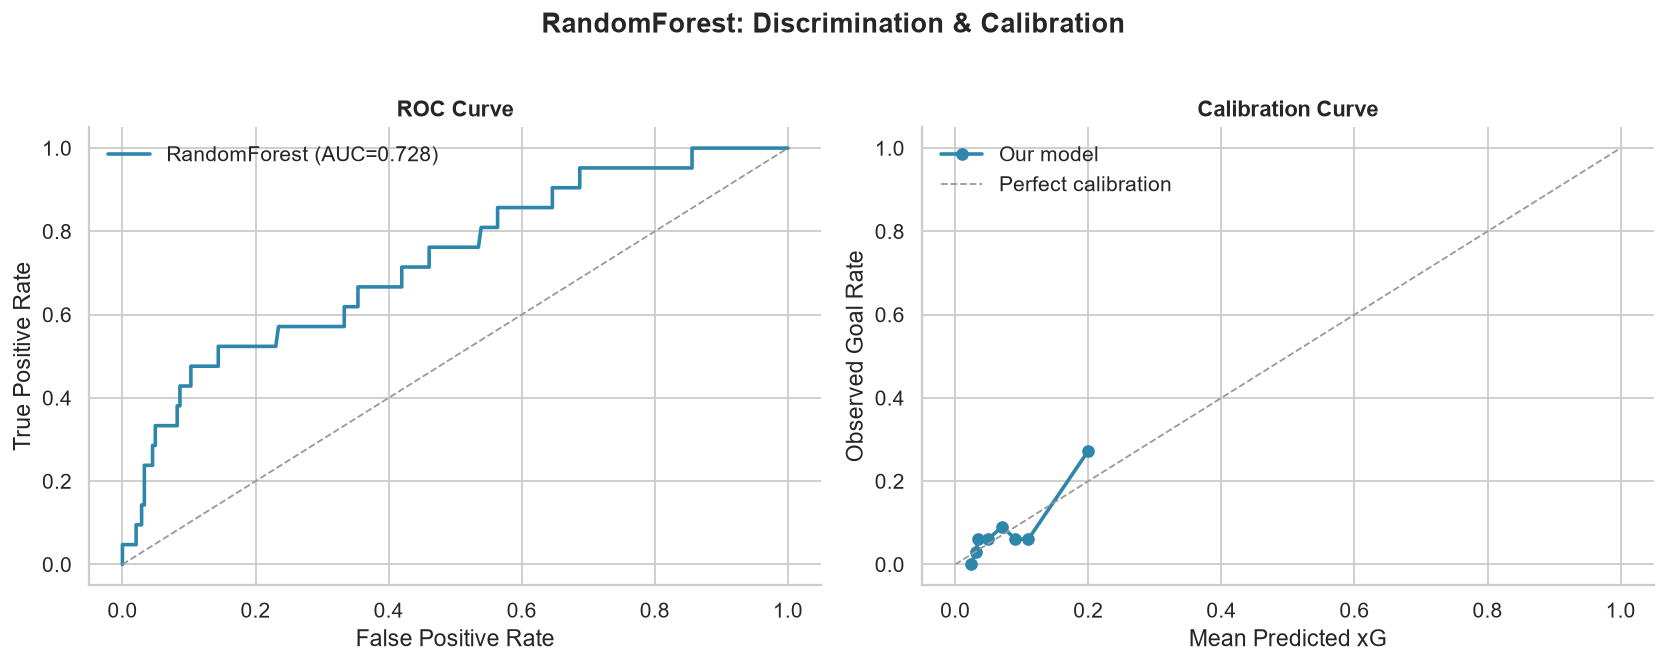

In [14]:
# ── 8.1  ROC curve & calibration curve ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
axes[0].plot(fpr, tpr, color=ACCENT, linewidth=2, label=f'{best_name} (AUC={results_df.iloc[0]["ROC AUC"]:.3f})')
axes[0].plot([0, 1], [0, 1], color='#999', linestyle='--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(frameon=False)

prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=8, strategy='quantile')
axes[1].plot(prob_pred, prob_true, marker='o', color=ACCENT, linewidth=2, label='Our model')
axes[1].plot([0, 1], [0, 1], color='#999', linestyle='--', linewidth=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted xG')
axes[1].set_ylabel('Observed Goal Rate')
axes[1].set_title('Calibration Curve')
axes[1].legend(frameon=False)

plt.suptitle(f'{best_name}: Discrimination & Calibration', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/best_model_predictions.png', bbox_inches='tight')
plt.show()

In [15]:
# ── 8.2  Compare against StatsBomb's own xG ────────────────────────────────────────────
sb_xg_test = df.loc[X_test.index, 'shot_statsbomb_xg']

sb_metrics = {
    'log_loss': log_loss(y_test, sb_xg_test.clip(1e-6, 1 - 1e-6)),
    'roc_auc':  roc_auc_score(y_test, sb_xg_test),
    'brier':    brier_score_loss(y_test, sb_xg_test),
}

comparison = pd.DataFrame({
    'Our Model':        [results_df.iloc[0]['Log Loss'], results_df.iloc[0]['ROC AUC'], results_df.iloc[0]['Brier']],
    'StatsBomb xG':      [round(sb_metrics['log_loss'], 4), round(sb_metrics['roc_auc'], 4), round(sb_metrics['brier'], 4)],
}, index=['Log Loss', 'ROC AUC', 'Brier'])
comparison

,Our Model,StatsBomb xG
Log Loss,0.2536,0.2304
ROC AUC,0.7278,0.8082
Brier,0.0690,0.0645


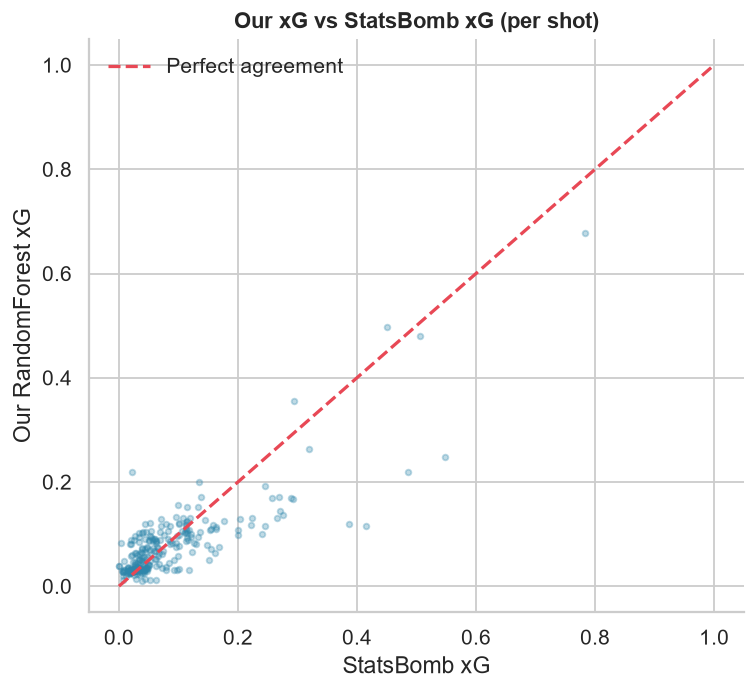

In [16]:
# ── 8.3  Residual analysis (our xG vs StatsBomb xG per shot) ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(sb_xg_test, y_proba_best, alpha=0.3, s=10, color=ACCENT)
ax.plot([0, 1], [0, 1], color=HIGHLIGHT, linewidth=1.8, linestyle='--', label='Perfect agreement')
ax.set_xlabel('StatsBomb xG')
ax.set_ylabel(f'Our {best_name} xG')
ax.set_title('Our xG vs StatsBomb xG (per shot)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('../outputs/residual_analysis.png', bbox_inches='tight')
plt.show()

<a id='9'></a>
## 9 · Feature Importance

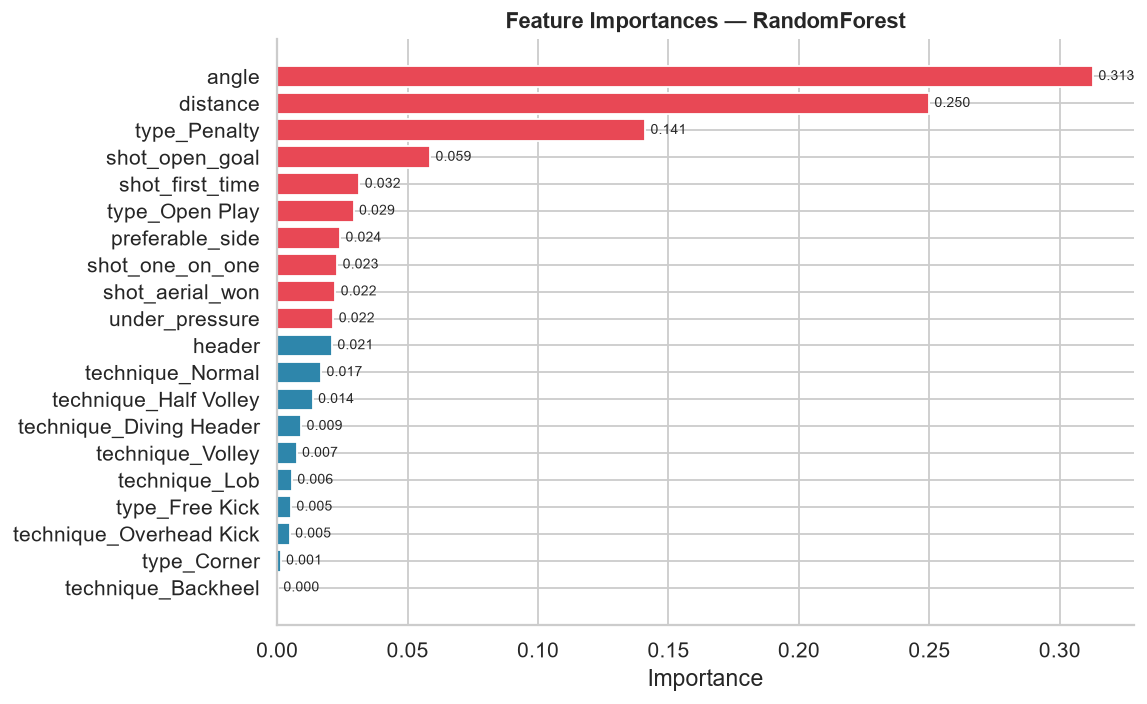

In [17]:
model_step = best_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=X.columns).sort_values(ascending=True)
elif hasattr(model_step, 'coef_'):
    importances = pd.Series(np.abs(model_step.coef_[0]), index=X.columns).sort_values(ascending=True)
else:
    importances = None

if importances is not None:
    fig, ax = plt.subplots(figsize=(9, max(4, 0.28 * len(importances))))
    colors_fi = [HIGHLIGHT if v > importances.median() else ACCENT for v in importances.values]
    bars = ax.barh(importances.index, importances.values, color=colors_fi, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importances — {best_name}')
    plt.tight_layout()
    plt.savefig('../outputs/feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    print(f'{best_name} does not expose feature importances directly.')

<a id='10'></a>
## 10 · Team Over/Underperformance

A classic use of xG: sum a team's shot xG across the tournament and compare it to their
actual goals scored. Teams scoring well above their xG are finishing clinically (or getting
lucky); teams well below are creating good chances but wasting them.

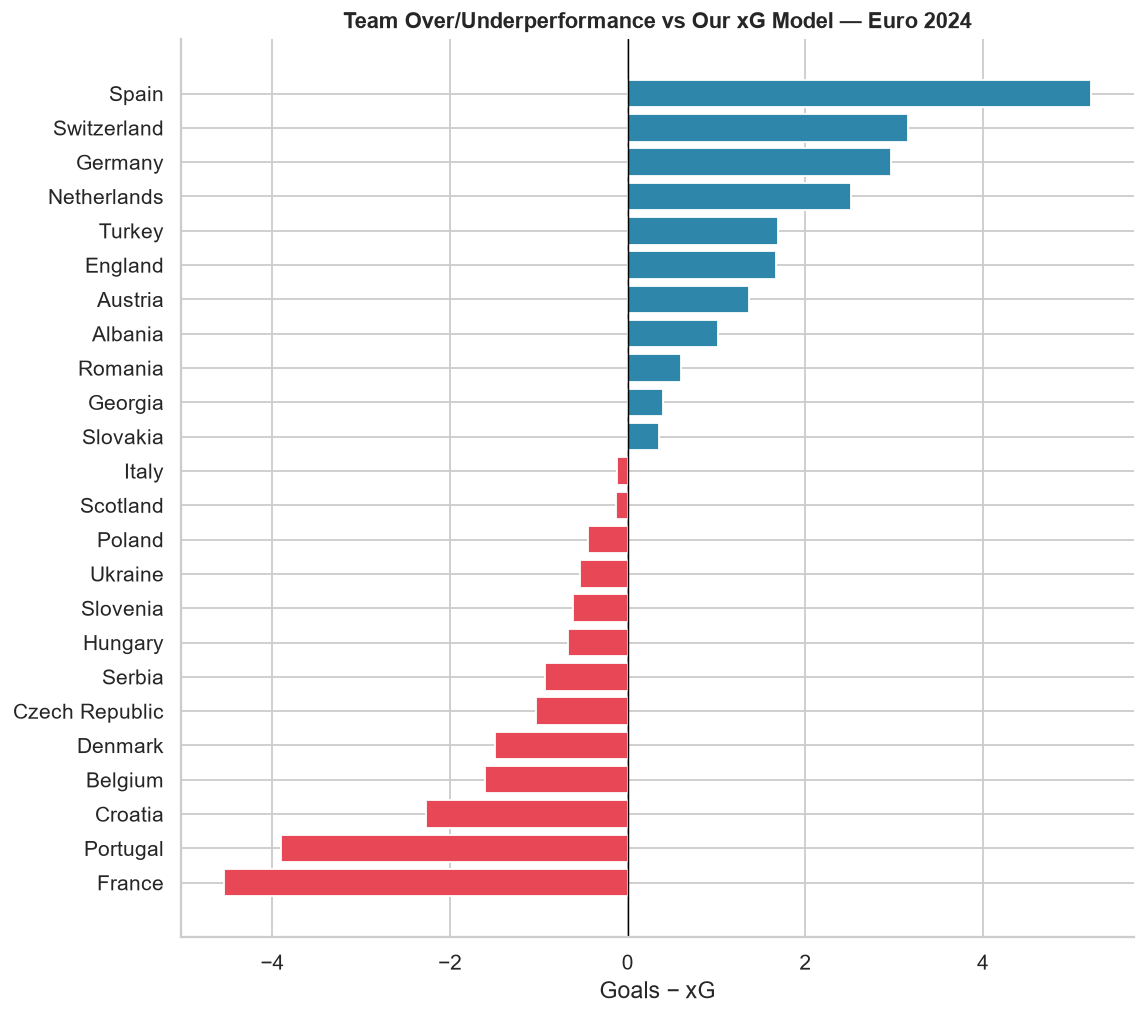

,team_name,shots,goals,our_xg,sb_xg,difference
20,Spain,123,14,8.79,10.56,5.21
21,Switzerland,58,8,4.85,5.35,3.15
9,Germany,95,11,8.04,8.73,2.96
12,Netherlands,83,9,6.49,7.32,2.51
22,Turkey,72,8,6.31,6.46,1.69
6,England,76,8,6.33,6.57,1.67
1,Austria,50,6,4.63,6.11,1.37
0,Albania,32,3,1.98,2.18,1.02
15,Romania,38,4,3.40,3.76,0.60
8,Georgia,30,4,3.60,4.22,0.40


In [18]:
df_all = df.copy()
df_all['our_xg'] = best_pipeline.predict_proba(X.reindex(df_all.index))[:, 1]

team_summary = df_all.groupby('team_name').agg(
    shots=('goal', 'size'),
    goals=('goal', 'sum'),
    our_xg=('our_xg', 'sum'),
    sb_xg=('shot_statsbomb_xg', 'sum'),
).reset_index()
team_summary['difference'] = team_summary['goals'] - team_summary['our_xg']
team_summary = team_summary.sort_values('difference', ascending=False).round(2)

fig, ax = plt.subplots(figsize=(9, 8))
colors_team = [ACCENT if v >= 0 else HIGHLIGHT for v in team_summary['difference']]
ax.barh(team_summary['team_name'][::-1], team_summary['difference'][::-1], color=colors_team[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Goals − xG')
ax.set_title('Team Over/Underperformance vs Our xG Model — Euro 2024')
plt.tight_layout()
plt.savefig('../outputs/team_overperformance.png', bbox_inches='tight')
plt.show()

team_summary.head(10)

<a id='11'></a>
## 11 · Summary

---

In [19]:
best_row = results_df.iloc[0]
print("=" * 50)
print(" EURO 2024 xG MODEL — RESULTS")
print("=" * 50)
print(f"  Best model : {best_row['Model']}")
print(f"  Log Loss   : {best_row['Log Loss']}")
print(f"  ROC AUC    : {best_row['ROC AUC']}")
print(f"  Brier      : {best_row['Brier']}")
print("=" * 50)
print()
print("All model results (sorted by Log Loss):")
print(results_df.to_string(index=False))

 EURO 2024 xG MODEL — RESULTS
  Best model : RandomForest
  Log Loss   : 0.2536
  ROC AUC    : 0.7278
  Brier      : 0.069

All model results (sorted by Log Loss):
               Model  CV AUC  CV Std  Log Loss  ROC AUC  Brier
        RandomForest  0.7658  0.0336    0.2536   0.7278 0.0690
  LogisticRegression  0.7507  0.0323    0.2557   0.7370 0.0710
    GradientBoosting  0.7317  0.0191    0.2828   0.6685 0.0764
HistGradientBoosting  0.7421  0.0494    0.4296   0.6265 0.0875


---

### Key Findings

- **Angle and distance** dominate as predictors, consistent with the geometric intuition
  behind xG: wide, close-range chances score far more often than tight-angle, long-range shots.
- **Shot type** matters a lot — penalties carry a much higher baseline scoring probability
  than any open-play feature combination can replicate.
- Our from-scratch model, trained on ~2,000 shots, tracks StatsBomb's proprietary xG
  reasonably closely on log loss and calibration, despite using far fewer features
  (no freeze-frame defender positions, no goalkeeper positioning).
- Team over/underperformance vs. xG highlights finishing quality independent of chance volume
  — useful for separating "created lots of shots" from "actually clinical in front of goal."
